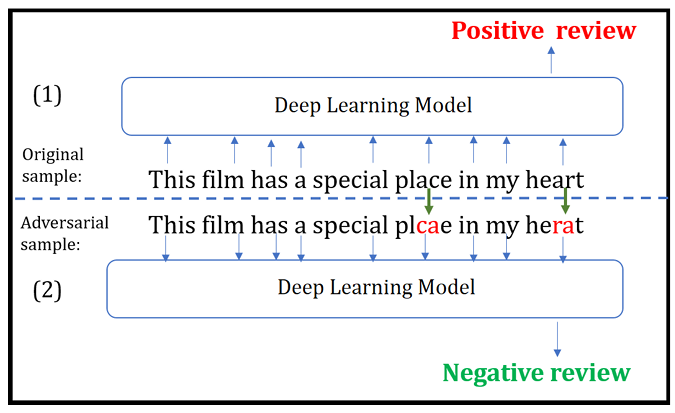

DeepWordBug Attack Flow:

---

### **Two-Step Process**
1. **Token Scoring and Ranking**:
   - Use scoring functions (e.g., Replace-1 Score, Temporal Head Score, Temporal Tail Score, Combined Score) to identify the most important tokens influencing the classifier's decision.
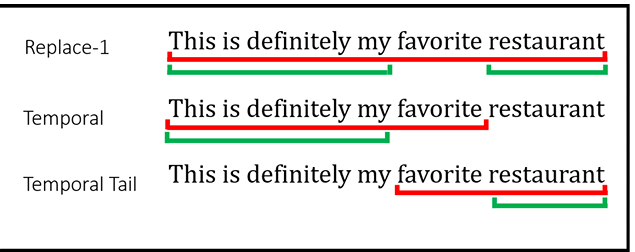

---



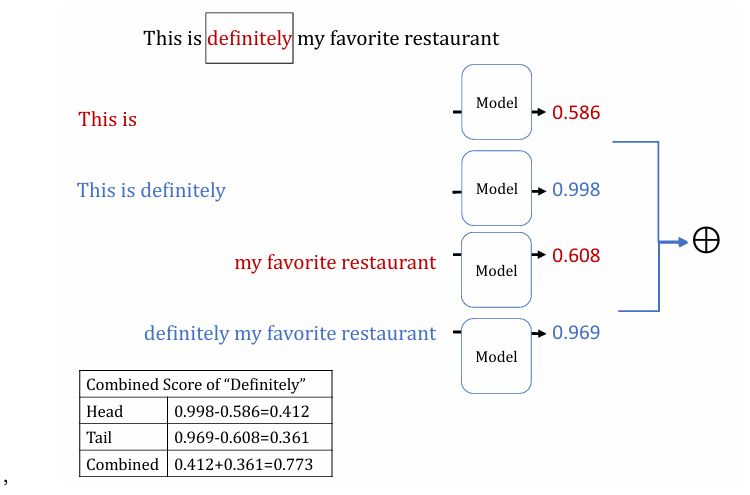







2. **Token Transformation**:
   - Apply character-level modifications (swap, substitution, deletion, insertion) to the highest-ranked tokens while ensuring minimal edit distance (Levenshtein distance) to keep perturbations imperceptible.



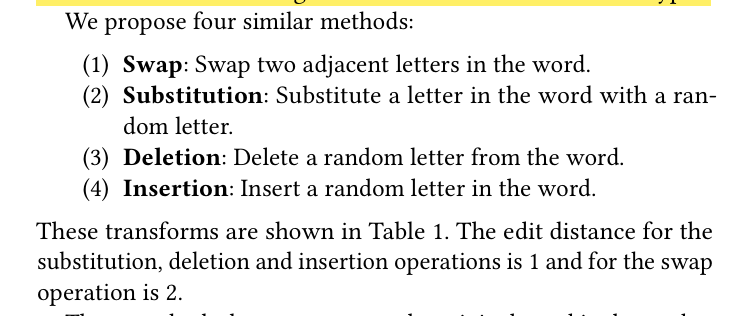

In [1]:
from tensorflow.keras.models import load_model
import pickle

# Load the model
model = load_model('NLPModel.h5')

# Load the tokenizer
with open('tokenizer.pickle', 'rb') as f:
    tokenizer = pickle.load(f)

In [44]:
import tensorflow as tf
import numpy as np
from typing import List, Tuple
import random
import string
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
class DeepWordBug:
    def __init__(self, model_path: str, tokenizer, max_length: int = 200, scaling_factor: float = 0.1, max_epsilon: int = 30, strategy: str = "proportional", lambda_param: float = 0.5):
        """
        Initialize DeepWordBug attack for TensorFlow model.

        Args:
            model_path: Path to saved Keras model
            tokenizer: Keras tokenizer used for the model
            max_length: Maximum sequence length for padding
            scaling_factor: A factor to scale epsilon relative to text length
            max_epsilon: The maximum allowed epsilon value
            strategy: Strategy for calculating epsilon ("proportional" or "fixed")
            lambda_param: Weight for combining temporal scoring function
        """
        self.model = keras.models.load_model('NLPModel.h5')
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.scaling_factor = scaling_factor
        self.max_epsilon = max_epsilon
        self.strategy = strategy
        self.lambda_param = lambda_param

    def calculate_epsilon(self, text: str) -> int:
        """
        Calculates epsilon (maximum edit distance) for DeepWordBug based on text length and a scaling strategy.

        Args:
            text (str): The input text.

        Returns:
            int: The calculated epsilon value.
        """
        words = text.split()
        num_words = len(words)

        if self.strategy == "proportional":
            epsilon = int(num_words * self.scaling_factor)  # Epsilon proportional to text length
            epsilon = min(epsilon, self.max_epsilon)  # Cap epsilon at max_epsilon
        elif self.strategy == "fixed":
            epsilon = self.max_epsilon  # Fixed epsilon value
        else:
            raise ValueError("Invalid epsilon calculation strategy.")

        return epsilon

    def predict(self, text: str) -> float:
        """Get model prediction for a text input."""
        sequence = self.tokenizer.texts_to_sequences([text])
        padded = pad_sequences(sequence, maxlen=self.max_length, padding='post', truncating='post')
        prediction = self.model.predict(padded, verbose=0)[0][0]
        return prediction

    def score_r1s(self, text: str, word_position: int) -> float:
        """Calculate Replace-1 Score for a word."""
        words = text.split()
        original_score = self.predict(text)

        if 0 <= word_position < len(words):
            modified_words = words.copy()
            modified_words[word_position] = '<UNK>'
            modified_text = ' '.join(modified_words)
            modified_score = self.predict(modified_text)
            return abs(original_score - modified_score)
        return 0.0

    def score_ths(self, text: str, word_position: int) -> float:
        """Calculate Temporal Head Score."""
        words = text.split()
        if 0 <= word_position < len(words):
            head_text = ' '.join(words[:word_position + 1])
            partial_text = ' '.join(words[:word_position])
            return abs(self.predict(head_text) - self.predict(partial_text))
        return 0.0

    def score_tts(self, text: str, word_position: int) -> float:
        """Calculate Temporal Tail Score."""
        words = text.split()
        if 0 <= word_position < len(words):
            tail_text = ' '.join(words[word_position:])
            partial_text = ' '.join(words[word_position + 1:])
            return abs(self.predict(tail_text) - self.predict(partial_text))
        return 0.0

    def score_combined(self, text: str, word_position: int) -> float:
        """Calculate Combined Score using THS and TTS."""
        ths = self.score_ths(text, word_position)
        tts = self.score_tts(text, word_position)
        return ths + self.lambda_param * tts

    def transform_token(self, token: str, method: str = None) -> str:
        """Transform a token using various methods."""
        if len(token) <= 1:
            return token

        methods = ['swap', 'substitute', 'delete', 'insert']
        method = method or random.choice(methods)

        if method == 'swap':
            pos = random.randint(0, len(token) - 2)
            chars = list(token)
            chars[pos], chars[pos + 1] = chars[pos + 1], chars[pos]
            return ''.join(chars)

        elif method == 'substitute':
            pos = random.randint(0, len(token) - 1)
            chars = list(token)
            chars[pos] = random.choice(string.ascii_lowercase)
            return ''.join(chars)

        elif method == 'delete':
            pos = random.randint(0, len(token) - 1)
            return token[:pos] + token[pos + 1:]

        elif method == 'insert':
            pos = random.randint(0, len(token))
            char = random.choice(string.ascii_lowercase)
            return token[:pos] + char + token[pos:]

    def calculate_edit_distance(self, s1: str, s2: str) -> int:
        """Calculate Levenshtein distance between two strings."""
        if len(s1) < len(s2):
            return self.calculate_edit_distance(s2, s1)

        if len(s2) == 0:
            return len(s1)

        previous_row = range(len(s2) + 1)
        for i, c1 in enumerate(s1):
            current_row = [i + 1]
            for j, c2 in enumerate(s2):
                insertions = previous_row[j + 1] + 1
                deletions = current_row[j] + 1
                substitutions = previous_row[j] + (c1 != c2)
                current_row.append(min(insertions, deletions, substitutions))
            previous_row = current_row

        return previous_row[-1]

    def attack(self, text: str, scoring_method: str = 'r1s') -> Tuple[str, float, float]:
        """
        Generate adversarial text using DeepWordBug attack.

        Args:
            text: Input text to attack
            scoring_method: Method to score tokens ('r1s', 'ths', 'tts', 'combined')

        Returns:
            Tuple of (adversarial_text, original_score, adversarial_score)
        """
        words = text.split()
        original_score = self.predict(text)

        # Calculate epsilon based on the text length
        epsilon = self.calculate_epsilon(text)

        # Score each word
        scores = []
        for i, word in enumerate(words):
            if scoring_method == 'r1s':
                score = self.score_r1s(text, i)
            elif scoring_method == 'ths':
                score = self.score_ths(text, i)
            elif scoring_method == 'tts':
                score = self.score_tts(text, i)
            else:  # combined
                score = self.score_combined(text, i)
            scores.append((i, score))

        # Sort words by importance score
        sorted_words = sorted(scores, key=lambda x: x[1], reverse=True)

        # Modify words while respecting the total edit distance limit
        modified_words = words.copy()
        total_edit_distance = 0

        for idx, _ in sorted_words:
            original_word = words[idx]
            modified_word = self.transform_token(original_word)

            # Calculate edit distance for this modification
            edit_dist = self.calculate_edit_distance(original_word, modified_word)

            # Check if the total edit distance exceeds epsilon
            if total_edit_distance + edit_dist > epsilon:
                continue  # Skip this modification to stay within the limit

            # Apply the modification
            modified_words[idx] = modified_word
            total_edit_distance += edit_dist

        adversarial_text = ' '.join(modified_words)
        adversarial_score = self.predict(adversarial_text)

        return adversarial_text, original_score, adversarial_score

# Example usage
if __name__ == "__main__":
    attack = DeepWordBug(
        model_path='NLPModel.h5',
        tokenizer=tokenizer,  # My saved tokenizer
        max_length=200,
        scaling_factor=0.2,
        max_epsilon=5,
        strategy="proportional"
    )


In [34]:
def printing_results(text, orig_score, adv_text, adv_score):
    # Predict sentiment of the original text
    sentiment_orig, confidence_orig = predict_sentiment(model, text, tokenizer)

    # Predict sentiment of the adversarial text
    sentiment_adversarial, confidence_adversarial = predict_sentiment(model, adv_text, tokenizer)

    # Print original results
    print(f"Original Sentiment: {sentiment_orig} (Confidence: {confidence_orig:.4f})")
    print("-" * 50)

    # Print adversarial results
    print(f"Adversarial Sentiment: {sentiment_adversarial} (Confidence: {confidence_adversarial:.4f})")
    print("-" * 50)

    # Print original and adversarial text/predictions
    print(f"Original text: {text}")
    print(f"Original prediction: {orig_score:.4f}")
    print(f"Adversarial text: {adv_text}")
    print(f"Adversarial prediction: {adv_score:.4f}")
    print("-" * 50)

    # Check if the attack succeeded
    if sentiment_orig != sentiment_adversarial:
        print("Attack SUCCEEDED: Sentiment flipped!")
    else:
        print("Attack FAILED: Sentiment did not flip.")

In [36]:
 # Test the attack
text = "This restaurant was excellent and I really enjoyed the service"
adv_text, orig_score, adv_score = attack.attack(text)

printing_results(text,orig_score,adv_text,adv_score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Original Sentiment: Positive (Confidence: 0.9946)
--------------------------------------------------
Adversarial Sentiment: Negative (Confidence: 0.7077)
--------------------------------------------------
Original text: This restaurant was excellent and I really enjoyed the service
Original prediction: 0.9946
Adversarial text: This restaurant was exlcellent and I really etnjoyed the service
Adversarial prediction: 0.2923
--------------------------------------------------
Attack SUCCEEDED: Sentiment flipped!


In [49]:
# Test the attack
text2="This food was so bad"
adv_text2, orig_score2, adv_score2= attack.attack(text2)
printing_results(text2,orig_score2,adv_text2,adv_score2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Original Sentiment: Negative (Confidence: 0.9929)
--------------------------------------------------
Adversarial Sentiment: Negative (Confidence: 0.9529)
--------------------------------------------------
Original text: This food was so bad
Original prediction: 0.0071
Adversarial text: This food was so bayd
Adversarial prediction: 0.0471
--------------------------------------------------
Attack FAILED: Sentiment did not flip.


In [46]:
# Test the attack
text3 = "I loved the food so much"
adv_text3, orig_score3, adv_score3 = attack.attack(text3)
printing_results(text3,orig_score3,adv_text3,adv_score3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Original Sentiment: Positive (Confidence: 0.8359)
--------------------------------------------------
Adversarial Sentiment: Negative (Confidence: 0.8747)
--------------------------------------------------
Original text: I loved the food so much
Original prediction: 0.8359
Adversarial text: I laved the food so much
Adversarial prediction: 0.1253
--------------------------------------------------
Attack SUCCEEDED: Sentiment flipped!


In [66]:
 # Test the attack
text = "This restaurant was excellent and I really enjoyed the service"
adv_text, orig_score, adv_score = attack.attack(text)

printing_results(text,orig_score,adv_text,adv_score)

Scoring each word:
R1S: Word Position 0, Original Score: 0.9946383833885193, Modified Score: 0.9943259358406067, R1S Score: 0.00031244754791259766
Word: 'This', Position: 0, Score: 0.00031244754791259766
R1S: Word Position 1, Original Score: 0.9946383833885193, Modified Score: 0.9947572946548462, R1S Score: 0.0001189112663269043
Word: 'restaurant', Position: 1, Score: 0.0001189112663269043
R1S: Word Position 2, Original Score: 0.9946383833885193, Modified Score: 0.9945901036262512, R1S Score: 4.8279762268066406e-05
Word: 'was', Position: 2, Score: 4.8279762268066406e-05
R1S: Word Position 3, Original Score: 0.9946383833885193, Modified Score: 0.9019200205802917, R1S Score: 0.09271836280822754
Word: 'excellent', Position: 3, Score: 0.09271836280822754
R1S: Word Position 4, Original Score: 0.9946383833885193, Modified Score: 0.9943812489509583, R1S Score: 0.00025713443756103516
Word: 'and', Position: 4, Score: 0.00025713443756103516
R1S: Word Position 5, Original Score: 0.994638383388519

In [82]:
 # Test the attack
text4 = "This was the worst restaurant I ate at"
adv_text4, orig_score4, adv_score4 = attack.attack(text4)

printing_results(text4,orig_score4,adv_text4,adv_score4)

Epsilon value= %d 1
Scoring each word:
R1S: Word Position 0, Original Score: 0.002904771827161312, Modified Score: 0.003268640721216798, R1S Score: 0.0003638688940554857
Word: 'This', Position: 0, Score: 0.0003638688940554857
R1S: Word Position 1, Original Score: 0.002904771827161312, Modified Score: 0.0032647978514432907, R1S Score: 0.0003600260242819786
Word: 'was', Position: 1, Score: 0.0003600260242819786
R1S: Word Position 2, Original Score: 0.002904771827161312, Modified Score: 0.0028765846509486437, R1S Score: 2.818717621266842e-05
Word: 'the', Position: 2, Score: 2.818717621266842e-05
R1S: Word Position 3, Original Score: 0.002904771827161312, Modified Score: 0.16325059533119202, R1S Score: 0.16034582257270813
Word: 'worst', Position: 3, Score: 0.16034582257270813
R1S: Word Position 4, Original Score: 0.002904771827161312, Modified Score: 0.0032018551137298346, R1S Score: 0.00029708328656852245
Word: 'restaurant', Position: 4, Score: 0.00029708328656852245
R1S: Word Position 5,